# 03 EDA Analysis

This notebook performs a production-ready exploratory data analysis for the Bluestock mutual fund platform using the local SQLite star schema at `../data/db/bluestock_mf.db` together with the curated CSV extracts in `../data/raw/` and `../data/processed/`.

## Notebook Flow

1. Connect to SQLite and load the star-schema tables.
2. Pull the supplemental AUM, SIP, folio, investor, scheme performance, category inflow, and portfolio holdings files.
3. Build nine publication-ready visualizations and save the static outputs to `../reports/`.
4. Finish with ten concise business findings that can be lifted into the capstone narrative.

In [1]:
%pip install pandas numpy matplotlib seaborn plotly kaleido nbformat
%pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline
from pathlib import Path
import sqlite3
import warnings
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, Markdown, HTML

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
pio.templates.default = 'plotly_white'
PLOTLY_PNG_FALLBACKS = {}

In [3]:
# Keep the notebook pathing aligned with the requested relative locations.
DB_CONNECTION_STRING = '../data/db/bluestock_mf.db'
if Path(DB_CONNECTION_STRING).exists():
    DATA_DIR = Path('../data')
    REPORTS_DIR = Path('../reports')
else:
    DATA_DIR = Path('data')
    REPORTS_DIR = Path('reports')

DB_PATH = DATA_DIR / 'db' / 'bluestock_mf.db'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH.as_posix())
conn.execute('PRAGMA foreign_keys = ON')


def read_sql(query: str, params=None) -> pd.DataFrame:
    # Run a parameterized SQL query against the local SQLite database.
    return pd.read_sql_query(query, conn, params=params)


def save_static_figure(fig, filename: str, dpi: int = 300):
    # Save a Matplotlib/Seaborn figure to the reports directory.
    output_path = REPORTS_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches='tight')
    return output_path


def save_plotly_figure(fig, stem: str):
    # Save an interactive Plotly figure as HTML and try to export a PNG snapshot.
    html_path = REPORTS_DIR / f'{stem}.html'
    png_path = REPORTS_DIR / f'{stem}.png'
    fig.write_html(html_path.as_posix(), include_plotlyjs='cdn')
    try:
        fig.write_image(png_path.as_posix(), scale=2)
    except Exception as exc:
        print(f'Plotly PNG export skipped for {stem}: {exc}')
    if not png_path.exists() and stem in PLOTLY_PNG_FALLBACKS:
        print(f'Creating PNG fallback for {stem} with Matplotlib...')
        PLOTLY_PNG_FALLBACKS[stem](png_path)
    return html_path

In [4]:
# Load the star-schema tables from SQLite and the complementary CSV extracts.
fund_dim = read_sql('SELECT * FROM dim_fund ORDER BY amfi_code')
nav_df = read_sql('''
    SELECT
        n.nav_date,
        n.amfi_code,
        d.scheme_name,
        d.fund_house,
        d.category,
        d.sub_category,
        n.nav
    FROM fact_nav AS n
    INNER JOIN dim_fund AS d
        ON n.amfi_code = d.amfi_code
''')
transaction_df = read_sql('''
    SELECT
        t.transaction_date,
        t.amfi_code,
        d.scheme_name,
        d.fund_house,
        d.category,
        d.sub_category,
        t.investor_id,
        t.amount_inr,
        t.transaction_type,
        t.state,
        t.city_tier
    FROM fact_transactions AS t
    INNER JOIN dim_fund AS d
        ON t.amfi_code = d.amfi_code
''')

aum_df = pd.read_csv(DATA_DIR / 'raw' / '03_aum_by_fund_house.csv')
sip_df = pd.read_csv(DATA_DIR / 'raw' / '04_monthly_sip_inflows.csv')
category_df = pd.read_csv(DATA_DIR / 'raw' / '05_category_inflows.csv')
folio_df = pd.read_csv(DATA_DIR / 'raw' / '06_industry_folio_count.csv')
investor_df = pd.read_csv(DATA_DIR / 'processed' / 'clean_08_investor_transactions.csv')
performance_df = pd.read_csv(DATA_DIR / 'processed' / 'clean_07_scheme_performance.csv')
holdings_df = pd.read_csv(DATA_DIR / 'raw' / '09_portfolio_holdings.csv')

# Normalize date fields for downstream charting.
nav_df['nav_date'] = pd.to_datetime(nav_df['nav_date'])
transaction_df['transaction_date'] = pd.to_datetime(transaction_df['transaction_date'])
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['period_label'] = aum_df['date'].dt.strftime('%b-%y')
sip_df['month'] = pd.to_datetime(sip_df['month'])
sip_df['month_label'] = sip_df['month'].dt.strftime('%b-%y')
category_df['month'] = pd.to_datetime(category_df['month'])
category_df['month_label'] = category_df['month'].dt.strftime('%b-%y')
folio_df['month'] = pd.to_datetime(folio_df['month'])
folio_df['month_label'] = folio_df['month'].dt.strftime('%b-%y')
investor_df['transaction_date'] = pd.to_datetime(investor_df['transaction_date'])
holdings_df['portfolio_date'] = pd.to_datetime(holdings_df['portfolio_date'])

# Quick sanity snapshot for the notebook output.
print(f'Fund dimension rows: {len(fund_dim)}')
print(f'Daily NAV rows: {len(nav_df):,} across {nav_df["amfi_code"].nunique()} schemes')
print(f'Transaction rows: {len(transaction_df):,}')
print(f'AUM rows: {len(aum_df)}')
print(f'SIP rows: {len(sip_df)}')
print(f'Category inflow rows: {len(category_df)}')
print(f'Folio rows: {len(folio_df)}')
print(f'Investor transaction rows: {len(investor_df):,}')
print(f'Scheme performance rows: {len(performance_df)}')
print(f'Portfolio holdings rows: {len(holdings_df)}')

Fund dimension rows: 40
Daily NAV rows: 64,320 across 40 schemes
Transaction rows: 32,778
AUM rows: 90
SIP rows: 48
Category inflow rows: 144
Folio rows: 21
Investor transaction rows: 32,778
Scheme performance rows: 40
Portfolio holdings rows: 322


In [5]:
def render_nav_trends_png(output_path):
    fig, ax = plt.subplots(figsize=(18, 8))
    for idx, (scheme_name, scheme_group) in enumerate(nav_plot.groupby('scheme_name', sort=True)):
        ax.plot(
            scheme_group['nav_date'],
            scheme_group['nav'],
            linewidth=1.0,
            alpha=0.85,
            label=scheme_name,
        )
    ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), color='#2ecc71', alpha=0.12)
    ax.axvspan(pd.Timestamp('2024-04-01'), pd.Timestamp('2024-10-31'), color='#e74c3c', alpha=0.12)
    ax.text(pd.Timestamp('2023-01-03'), ax.get_ylim()[1], '2023 Bull Run', va='top', ha='left', fontsize=11, fontweight='bold')
    ax.text(pd.Timestamp('2024-04-03'), ax.get_ylim()[1], '2024 Market Corrections', va='top', ha='left', fontsize=11, fontweight='bold')
    ax.set_title('Daily NAV Trend Analysis Across All 40 Schemes (2022-2026)')
    ax.set_xlabel('NAV Date')
    ax.set_ylabel('NAV (₹)')
    ax.grid(True, alpha=0.25)
    ax.legend(title='Scheme', fontsize=5, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    fig.autofmt_xdate()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)


def render_sip_inflow_png(output_path):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(sip_plot['month'], sip_plot['sip_inflow_crore'], color='#1f77b4', marker='o', linewidth=2.5)
    ax.fill_between(sip_plot['month'], sip_plot['sip_inflow_crore'], color='#1f77b4', alpha=0.12)
    ax.annotate(
        'Historic record: ₹31,002 Cr',
        xy=(record_row['month'], record_row['sip_inflow_crore']),
        xytext=(record_row['month'], record_row['sip_inflow_crore'] + 1500),
        arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#1f77b4', alpha=0.95),
    )
    ax.set_title('Monthly SIP Inflow Momentum (Jan 2022 to Dec 2025)')
    ax.set_xlabel('Month')
    ax.set_ylabel('SIP Inflow (₹ Crore)')
    ax.grid(True, alpha=0.25)
    fig.autofmt_xdate()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)


def render_folio_growth_png(output_path):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(folio_plot['month'], folio_plot['total_folios_crore'], color='#0b7285', marker='o', linewidth=2.5)
    ax.fill_between(folio_plot['month'], folio_plot['total_folios_crore'], color='#0b7285', alpha=0.12)
    ax.annotate(
        f"{start_row['total_folios_crore']:.2f} Cr",
        xy=(start_row['month'], start_row['total_folios_crore']),
        xytext=(start_row['month'], start_row['total_folios_crore'] + 1.1),
        arrowprops=dict(arrowstyle='->', color='#0b7285', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#0b7285', alpha=0.95),
    )
    ax.annotate(
        f"{end_row['total_folios_crore']:.2f} Cr",
        xy=(end_row['month'], end_row['total_folios_crore']),
        xytext=(end_row['month'], end_row['total_folios_crore'] + 1.1),
        arrowprops=dict(arrowstyle='->', color='#0b7285', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#0b7285', alpha=0.95),
    )
    ax.set_title('Industry Folio Count Growth (Jan 2022 to Dec 2025)')
    ax.set_xlabel('Month')
    ax.set_ylabel('Total Folios')
    ax.grid(True, alpha=0.25)
    fig.autofmt_xdate()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)


PLOTLY_PNG_FALLBACKS.update({
    '01_nav_trends': render_nav_trends_png,
    '02_sip_inflows': render_sip_inflow_png,
    '03_folio_growth': render_folio_growth_png,
})


## Chart 1: NAV Trend Analysis

This chart uses Plotly Graph Objects to trace all 40 schemes from the SQLite NAV fact table and overlays macro regime windows for the 2023 bull run and the 2024 correction phase.

In [6]:
# Chart 1: Daily NAV trend lines for all schemes with regime overlays.
nav_plot = nav_df.loc[(nav_df['nav_date'] >= '2022-01-01') & (nav_df['nav_date'] <= '2026-12-31')].copy()
nav_plot = nav_plot.sort_values(['scheme_name', 'nav_date'])

color_sequence = (
    px.colors.qualitative.Dark24
    + px.colors.qualitative.Alphabet
    + px.colors.qualitative.Set3
)

fig_nav = go.Figure()
for idx, (scheme_name, scheme_group) in enumerate(nav_plot.groupby('scheme_name', sort=True)):
    fig_nav.add_trace(
        go.Scattergl(
            x=scheme_group['nav_date'],
            y=scheme_group['nav'],
            mode='lines',
            name=scheme_name,
            line=dict(width=1.35, color=color_sequence[idx % len(color_sequence)]),
            hovertemplate=(
                '<b>%{fullData.name}</b><br>'
                'Date=%{x|%d-%b-%Y}<br>'
                'NAV=₹%{y:,.4f}<extra></extra>'
            ),
        )
    )

fig_nav.update_layout(
    title='Daily NAV Trend Analysis Across All 40 Schemes (2022-2026)',
    xaxis_title='NAV Date',
    yaxis_title='NAV (₹)',
    hovermode='x unified',
    height=780,
    legend_title_text='Scheme',
    margin=dict(l=40, r=30, t=80, b=40),
)

fig_nav.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='rgba(46, 204, 113, 0.12)',
    opacity=0.35,
    line_width=0,
    annotation_text='2023 Bull Run',
    annotation_position='top left',
)
fig_nav.add_vrect(
    x0='2024-04-01',
    x1='2024-10-31',
    fillcolor='rgba(231, 76, 60, 0.12)',
    opacity=0.35,
    line_width=0,
    annotation_text='2024 Market Corrections',
    annotation_position='top left',
)

fig_nav.update_xaxes(rangeslider_visible=False)
display(HTML(fig_nav.to_html(full_html=False, include_plotlyjs='cdn')))
save_plotly_figure(fig_nav, '01_nav_trends')

PosixPath('../reports/01_nav_trends.html')

## Chart 2: AUM Growth Grouped Bar Chart

This Seaborn grouped bar chart compares quarterly AMC AUM across the reported fund houses and highlights SBI Mutual Fund's peak dominance at ₹12.5 lakh crore.

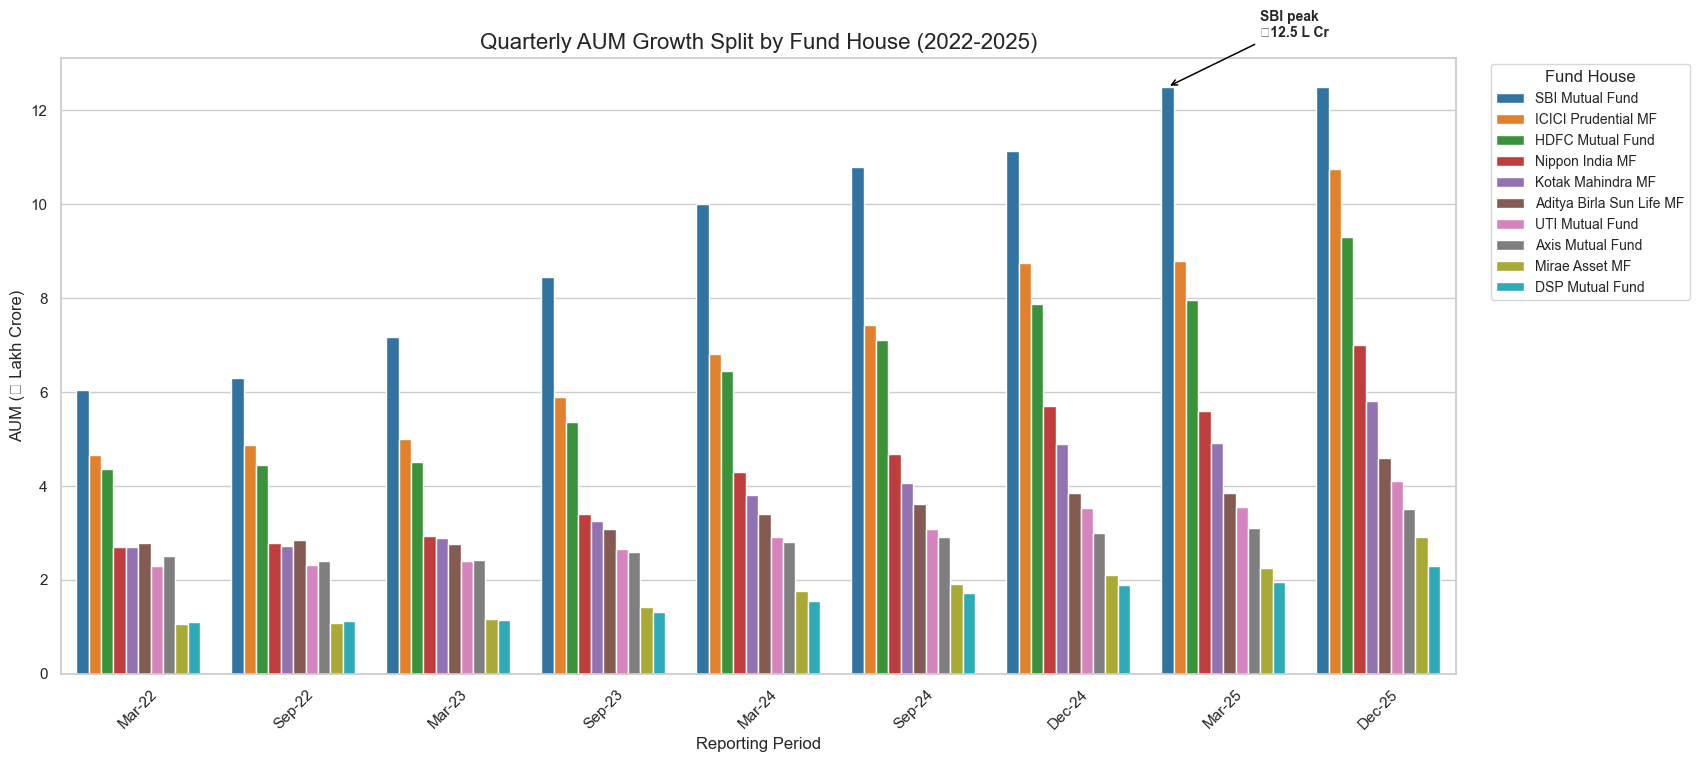

In [7]:
# Chart 2: Grouped AMC AUM bars by reporting period and fund house.
aum_order = aum_df.sort_values('date')['period_label'].drop_duplicates().tolist()
fund_order = (
    aum_df.groupby('fund_house')['aum_lakh_crore']
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.barplot(
    data=aum_df,
    x='period_label',
    y='aum_lakh_crore',
    hue='fund_house',
    order=aum_order,
    hue_order=fund_order,
    palette='tab10',
    ax=ax,
)

ax.set_title('Quarterly AUM Growth Split by Fund House (2022-2025)')
ax.set_xlabel('Reporting Period')
ax.set_ylabel('AUM (₹ Lakh Crore)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Fund House', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

peak_row = aum_df.loc[aum_df['aum_lakh_crore'].idxmax()]
peak_patch = max(ax.patches, key=lambda patch: patch.get_height())
peak_x = peak_patch.get_x() + peak_patch.get_width() / 2
peak_y = peak_patch.get_height()
ax.annotate(
    f"SBI peak\n₹{peak_row['aum_lakh_crore']:.1f} L Cr",
    xy=(peak_x, peak_y),
    xytext=(peak_x + 0.6, peak_y + 1.0),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.1),
    fontsize=10,
    fontweight='bold',
    ha='left',
    va='bottom',
)

save_static_figure(fig, '04_aum_growth.png')
plt.show()
plt.close(fig)

## Chart 3: SIP Inflow Time-Series

This Plotly line chart tracks monthly SIP inflows from January 2022 through December 2025 and annotates the historic December 2025 record of ₹31,002 crore.

In [8]:
# Chart 3: Monthly SIP inflows with a record-high annotation.
sip_plot = sip_df.loc[(sip_df['month'] >= '2022-01-01') & (sip_df['month'] <= '2025-12-31')].copy()
record_row = sip_plot.loc[sip_plot['sip_inflow_crore'].idxmax()]

fig_sip = go.Figure()
fig_sip.add_trace(
    go.Scatter(
        x=sip_plot['month'],
        y=sip_plot['sip_inflow_crore'],
        mode='lines+markers',
        name='Monthly SIP Inflow',
        line=dict(color='#1f77b4', width=3),
        marker=dict(size=7),
        fill='tozeroy',
        hovertemplate='Month=%{x|%b %Y}<br>SIP Inflow=₹%{y:,.0f} Cr<extra></extra>',
    )
)

fig_sip.add_annotation(
    x=record_row['month'],
    y=record_row['sip_inflow_crore'],
    text='Historic record: ₹31,002 Cr',
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=-70,
    bgcolor='white',
    bordercolor='#1f77b4',
    borderwidth=1,
)

fig_sip.update_layout(
    title='Monthly SIP Inflow Momentum (Jan 2022 to Dec 2025)',
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    hovermode='x unified',
    height=650,
    margin=dict(l=40, r=30, t=80, b=40),
)
fig_sip.update_xaxes(tickformat='%b-%y', rangeslider_visible=False)
display(HTML(fig_sip.to_html(full_html=False, include_plotlyjs='cdn')))
save_plotly_figure(fig_sip, '02_sip_inflows')

PosixPath('../reports/02_sip_inflows.html')

## Chart 4: Category Inflow Heatmap

This continuous monthly heatmap isolates the five requested fund categories and visualizes how net capital flowed across the 2024-2025 monthly window.

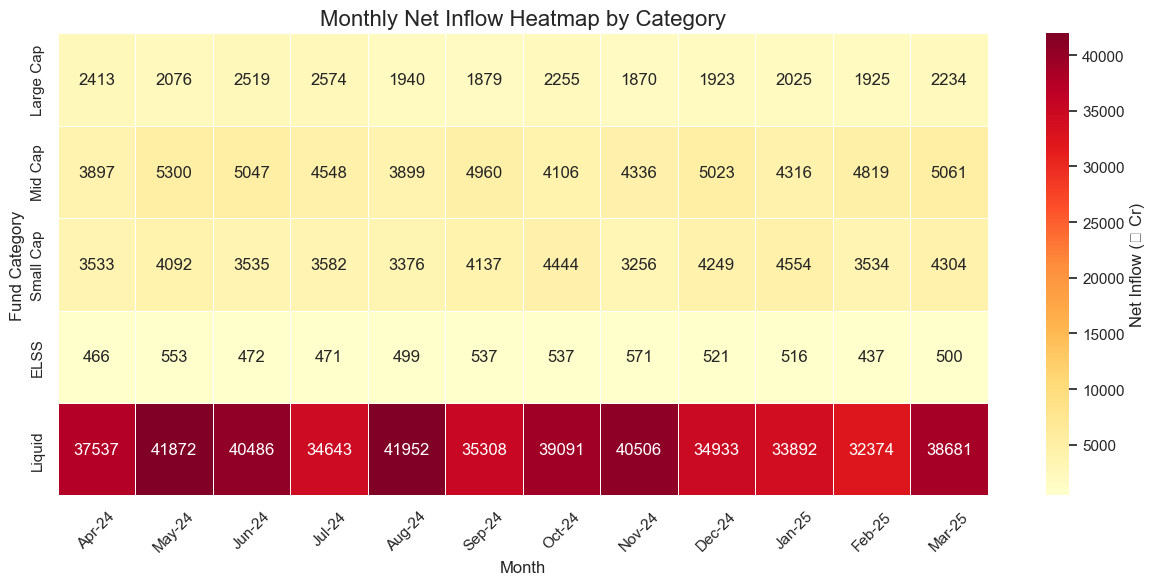

In [9]:
# Chart 4: Monthly category inflow intensity heatmap.
focus_categories = ['Large Cap', 'Mid Cap', 'Small Cap', 'ELSS', 'Liquid']
category_focus = category_df.loc[category_df['category'].isin(focus_categories)].copy()
month_order = category_focus.sort_values('month')['month_label'].drop_duplicates().tolist()
heatmap_matrix = (
    category_focus.pivot(index='category', columns='month_label', values='net_inflow_crore')
    .reindex(index=focus_categories, columns=month_order)
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    heatmap_matrix,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Net Inflow (₹ Cr)'},
    ax=ax,
)

ax.set_title('Monthly Net Inflow Heatmap by Category')
ax.set_xlabel('Month')
ax.set_ylabel('Fund Category')
ax.tick_params(axis='x', rotation=45)

save_static_figure(fig, '05_category_heatmap.png')
plt.show()
plt.close(fig)

## Chart 5: Investor Demographics Split

This three-panel layout combines age participation, SIP ticket distribution, and gender mix to expose the retail investor profile behind the transaction stream.

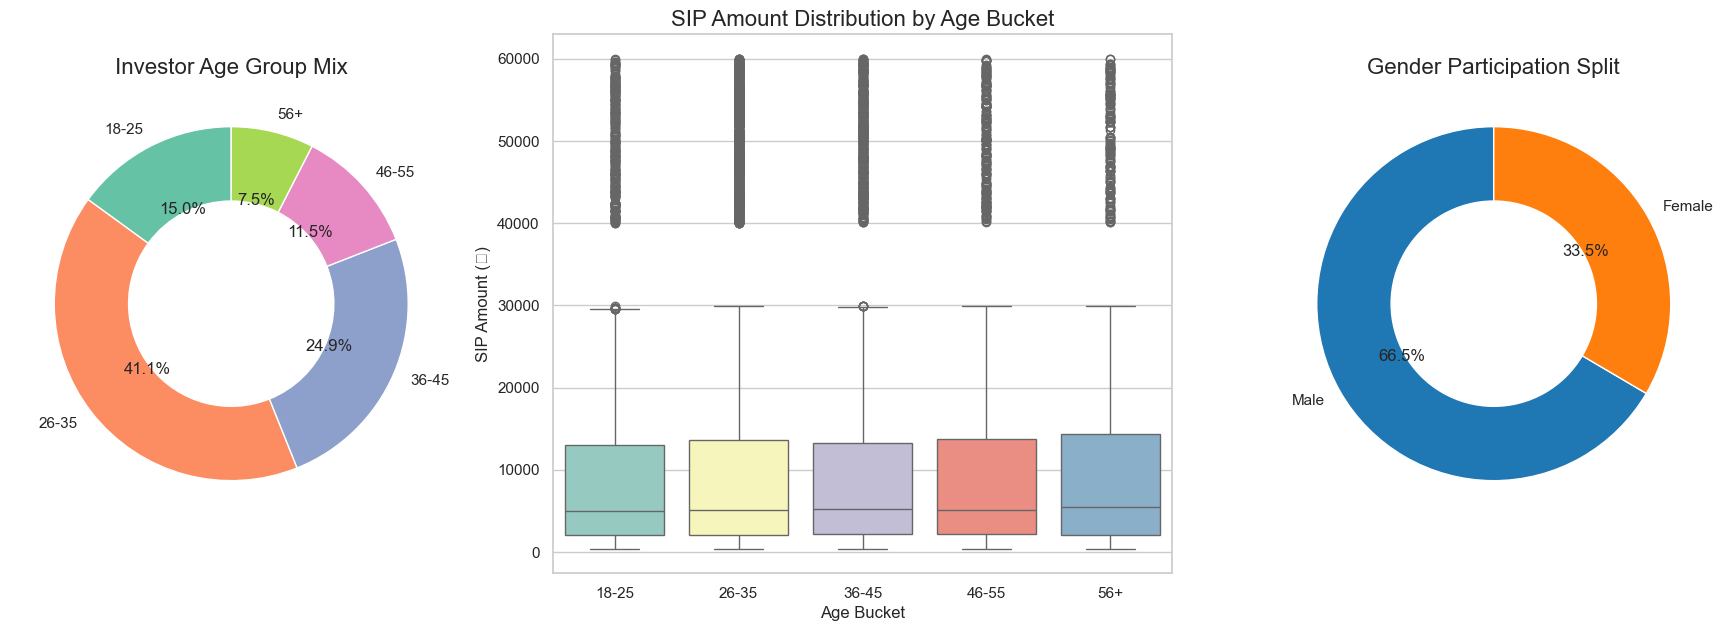

In [10]:
# Chart 5: Age distribution, SIP amount boxplot, and gender split.
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
age_counts = investor_df['age_group'].value_counts().reindex(age_order).fillna(0).astype(int)
gender_order = ['Male', 'Female']
gender_counts = investor_df['gender'].value_counts().reindex(gender_order).fillna(0).astype(int)
sip_only = investor_df.loc[investor_df['transaction_type'] == 'SIP'].copy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 7),
    gridspec_kw={'width_ratios': [1.0, 1.4, 1.0]},
)

age_colors = sns.color_palette('Set2', len(age_counts))
axes[0].pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=age_colors,
    wedgeprops=dict(width=0.42, edgecolor='white'),
)
axes[0].set_title('Investor Age Group Mix')

sns.boxplot(
    data=sip_only,
    x='age_group',
    y='amount_inr',
    order=age_order,
    palette='Set3',
    showfliers=True,
    ax=axes[1],
)
axes[1].set_title('SIP Amount Distribution by Age Bucket')
axes[1].set_xlabel('Age Bucket')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].tick_params(axis='x', rotation=0)

axes[2].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#1f77b4', '#ff7f0e'],
    wedgeprops=dict(width=0.42, edgecolor='white'),
)
axes[2].set_title('Gender Participation Split')

plt.show()
plt.close(fig)

## Chart 6: Geographic Distribution Profile

This panel pairs a state-level transaction value ranking with a T30-versus-B30 donut to show where capital is concentrated and how much of the activity comes from regional markets.

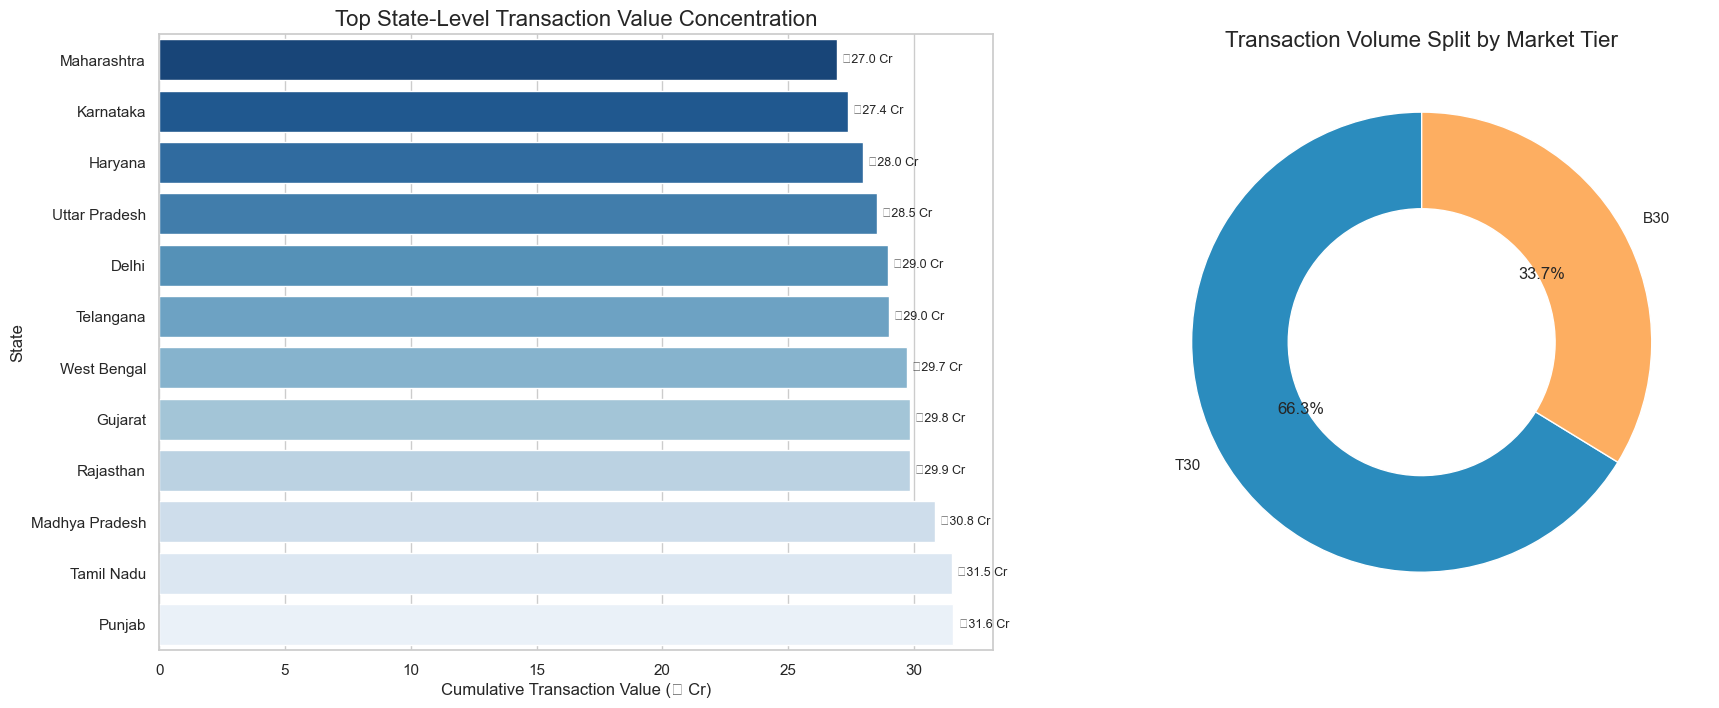

In [11]:
# Chart 6: State-level transaction value and T30/B30 split.
state_summary = (
    investor_df.groupby('state', as_index=False)['amount_inr']
    .sum()
    .sort_values('amount_inr', ascending=False)
    .head(12)
    .copy()
)
state_summary['amount_cr'] = state_summary['amount_inr'] / 1e7
state_summary = state_summary.sort_values('amount_cr')

tier_counts = investor_df['city_tier'].value_counts().reindex(['T30', 'B30']).fillna(0).astype(int)

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(20, 8),
    gridspec_kw={'width_ratios': [1.45, 1.0]},
)

state_palette = sns.color_palette('Blues_r', len(state_summary))
sns.barplot(
    data=state_summary,
    x='amount_cr',
    y='state',
    palette=state_palette,
    ax=ax1,
)
ax1.set_title('Top State-Level Transaction Value Concentration')
ax1.set_xlabel('Cumulative Transaction Value (₹ Cr)')
ax1.set_ylabel('State')
for patch, value in zip(ax1.patches, state_summary['amount_cr']):
    ax1.text(
        value + 0.2,
        patch.get_y() + patch.get_height() / 2,
        f'₹{value:,.1f} Cr',
        va='center',
        ha='left',
        fontsize=9,
    )

ax2.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2b8cbe', '#fdae61'],
    wedgeprops=dict(width=0.42, edgecolor='white'),
)
ax2.set_title('Transaction Volume Split by Market Tier')

plt.show()
plt.close(fig)

## Chart 7: Folio Count Growth

This Plotly time-series plot shows the industry folio acceleration curve from 13.26 crore folios in January 2022 to 26.12 crore folios in December 2025.

In [12]:
# Chart 7: Total folio growth with start and end-point annotations.
folio_plot = folio_df.loc[(folio_df['month'] >= '2022-01-01') & (folio_df['month'] <= '2025-12-31')].copy()
start_row = folio_plot.iloc[0]
end_row = folio_plot.iloc[-1]

fig_folio = go.Figure()
fig_folio.add_trace(
    go.Scatter(
        x=folio_plot['month'],
        y=folio_plot['total_folios_crore'],
        mode='lines+markers',
        name='Total Folios',
        line=dict(color='#0b7285', width=3),
        marker=dict(size=7),
        fill='tozeroy',
        hovertemplate='Month=%{x|%b %Y}<br>Total Folios=%{y:.2f} Cr<extra></extra>',
    )
)

fig_folio.add_annotation(
    x=start_row['month'],
    y=start_row['total_folios_crore'],
    text='13.26 Cr',
    showarrow=True,
    arrowhead=2,
    ax=-50,
    ay=50,
    bgcolor='white',
    bordercolor='#0b7285',
    borderwidth=1,
)
fig_folio.add_annotation(
    x=end_row['month'],
    y=end_row['total_folios_crore'],
    text='26.12 Cr',
    showarrow=True,
    arrowhead=2,
    ax=50,
    ay=-50,
    bgcolor='white',
    bordercolor='#0b7285',
    borderwidth=1,
)

fig_folio.update_layout(
    title='Industry Folio Count Growth (Jan 2022 to Dec 2025)',
    xaxis_title='Month',
    yaxis_title='Total Folios (₹ Crore equivalent scale)',
    hovermode='x unified',
    height=650,
    margin=dict(l=40, r=30, t=80, b=40),
)
fig_folio.update_xaxes(tickformat='%b-%y', rangeslider_visible=False)
display(HTML(fig_folio.to_html(full_html=False, include_plotlyjs='cdn')))
save_plotly_figure(fig_folio, '03_folio_growth')

PosixPath('../reports/03_folio_growth.html')

## Chart 8: Daily NAV Return Correlation Matrix

This heatmap computes pairwise Pearson correlations on daily NAV percentage changes for ten core schemes selected by AUM leadership.

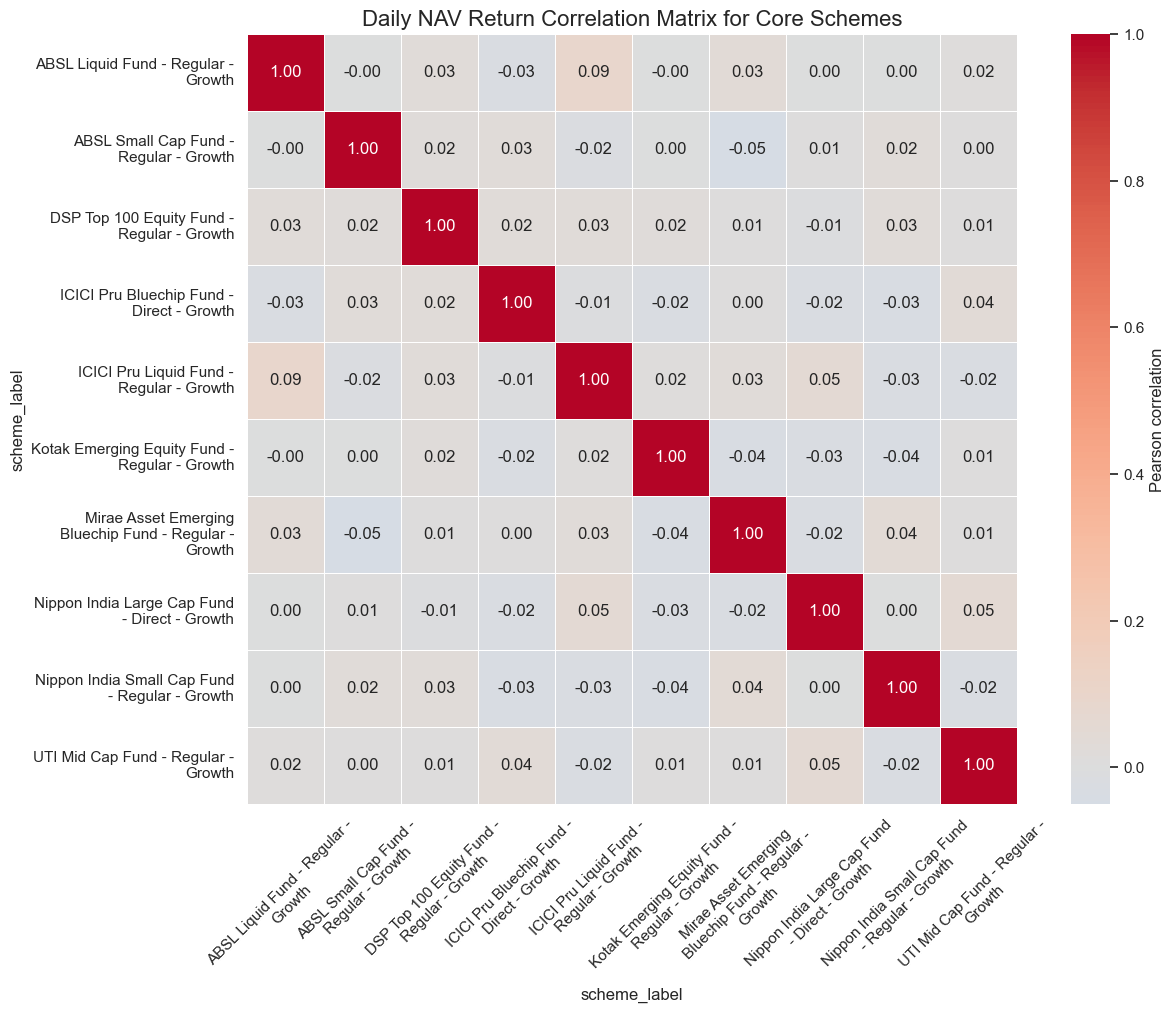

In [13]:
# Chart 8: Daily return correlation on a selected 10-scheme core book.
core_schemes = (
    performance_df.nlargest(10, 'aum_crore')
    .loc[:, ['amfi_code', 'scheme_name', 'aum_crore']]
    .copy()
)
core_nav = nav_df.loc[nav_df['amfi_code'].isin(core_schemes['amfi_code'])].copy()
core_nav['scheme_label'] = core_nav['scheme_name'].map(
    {name: textwrap.fill(name, width=28) for name in core_schemes['scheme_name']}
)

nav_pivot = (
    core_nav.pivot_table(index='nav_date', columns='scheme_label', values='nav', aggfunc='last')
    .sort_index()
)
nav_returns = nav_pivot.pct_change()
correlation_matrix = nav_returns.corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax,
)
ax.set_title('Daily NAV Return Correlation Matrix for Core Schemes')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

save_static_figure(fig, '11_return_correlation.png')
plt.show()
plt.close(fig)

## Chart 9: Portfolio Sector Allocation Donut Layout

This Matplotlib donut plot aggregates the latest portfolio holdings into structural sectors so the largest equity tilts are visible at a glance.

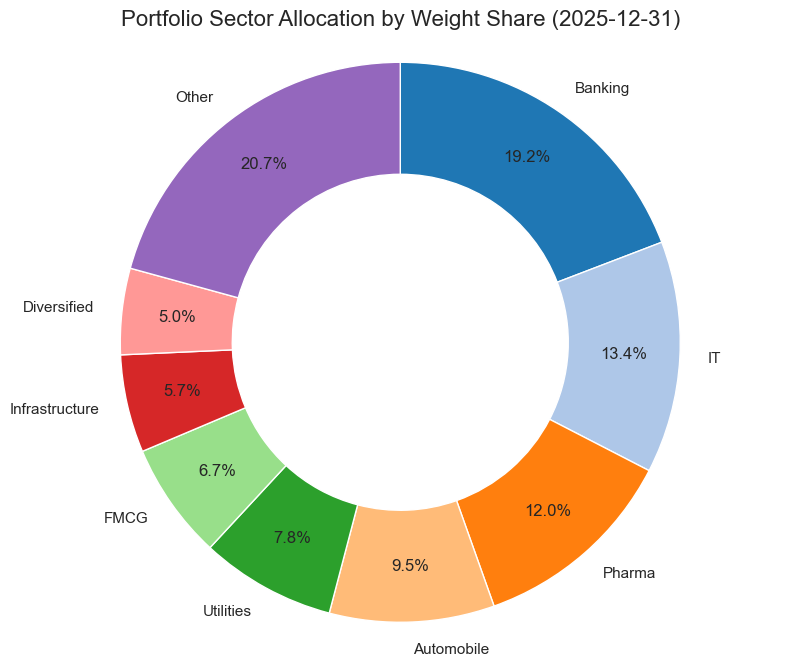

In [14]:
# Chart 9: Sector concentration from the latest portfolio snapshot.
latest_portfolio_date = holdings_df['portfolio_date'].max()
sector_df = (
    holdings_df.loc[holdings_df['portfolio_date'] == latest_portfolio_date]
    .groupby('sector', as_index=False)['weight_pct']
    .sum()
    .sort_values('weight_pct', ascending=False)
    .copy()
)
sector_df['share_pct'] = sector_df['weight_pct'] / sector_df['weight_pct'].sum() * 100

# Keep the donut readable by rolling the long tail into a single 'Other' slice.
plot_sector_df = sector_df.head(8).copy()
other_share = sector_df['share_pct'].iloc[8:].sum()
if other_share > 0:
    plot_sector_df = pd.concat(
        [
            plot_sector_df,
            pd.DataFrame([{'sector': 'Other', 'share_pct': other_share}]),
        ],
        ignore_index=True,
    )

fig, ax = plt.subplots(figsize=(10, 8))
sector_colors = sns.color_palette('tab20', len(plot_sector_df))
wedges, texts, autotexts = ax.pie(
    plot_sector_df['share_pct'],
    labels=plot_sector_df['sector'],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=sector_colors,
    wedgeprops=dict(width=0.40, edgecolor='white'),
    pctdistance=0.80,
)

center_circle = plt.Circle((0, 0), 0.52, fc='white')
ax.add_artist(center_circle)
ax.set_title(f'Portfolio Sector Allocation by Weight Share ({latest_portfolio_date.date()})')
ax.axis('equal')

save_static_figure(fig, '12_sector_donut.png')
plt.show()
plt.close(fig)

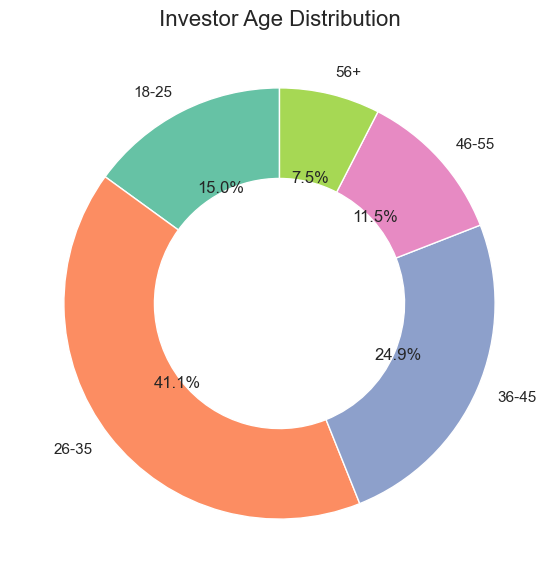

In [15]:
# Chart 6: Investor Age Distribution.
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
age_counts = investor_df['age_group'].value_counts().reindex(age_order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', len(age_counts)), wedgeprops=dict(width=0.42, edgecolor='white'))
ax.set_title('Investor Age Distribution')
save_static_figure(fig, '06_age_pie.png')
plt.show()
plt.close(fig)


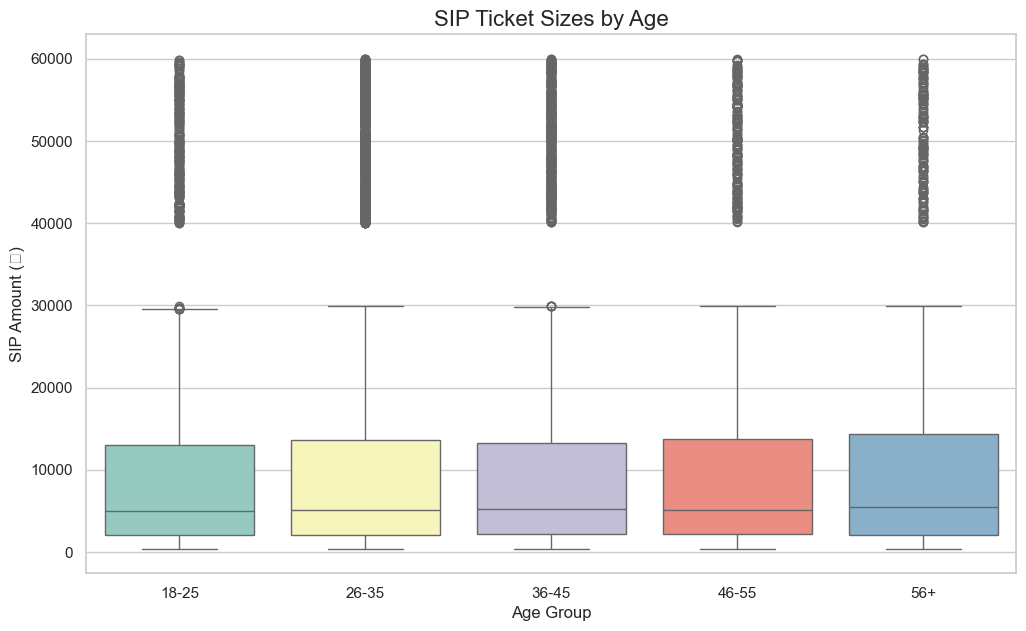

In [16]:
# Chart 7: SIP Ticket Sizes by Age.
sip_only = investor_df.loc[investor_df['transaction_type'] == 'SIP'].copy()
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=sip_only, x='age_group', y='amount_inr', order=age_order, palette='Set3', showfliers=True, ax=ax)
ax.set_title('SIP Ticket Sizes by Age')
ax.set_xlabel('Age Group')
ax.set_ylabel('SIP Amount (₹)')
save_static_figure(fig, '07_sip_boxplot.png')
plt.show()
plt.close(fig)


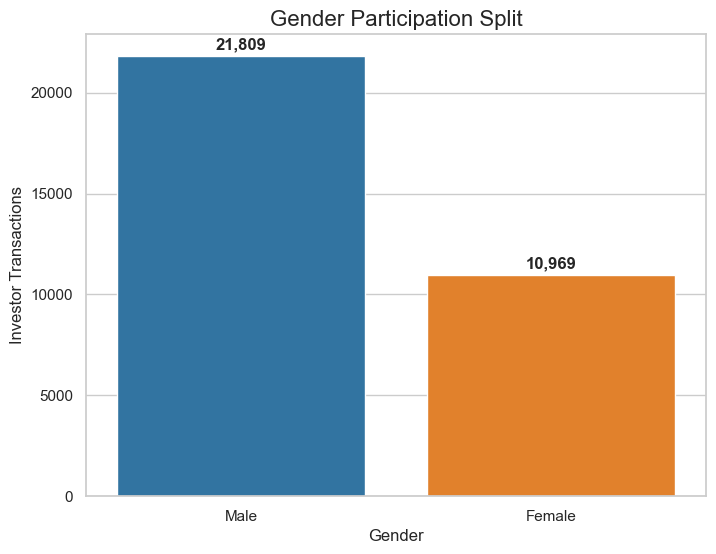

In [17]:
# Chart 8: Gender Participation Split.
gender_order = ['Male', 'Female']
gender_counts = investor_df['gender'].value_counts().reindex(gender_order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#1f77b4', '#ff7f0e'], ax=ax)
ax.set_title('Gender Participation Split')
ax.set_xlabel('Gender')
ax.set_ylabel('Investor Transactions')
for i, value in enumerate(gender_counts.values):
    ax.text(i, value + 200, f'{value:,}', ha='center', va='bottom', fontweight='bold')
save_static_figure(fig, '08_gender_split.png')
plt.show()
plt.close(fig)


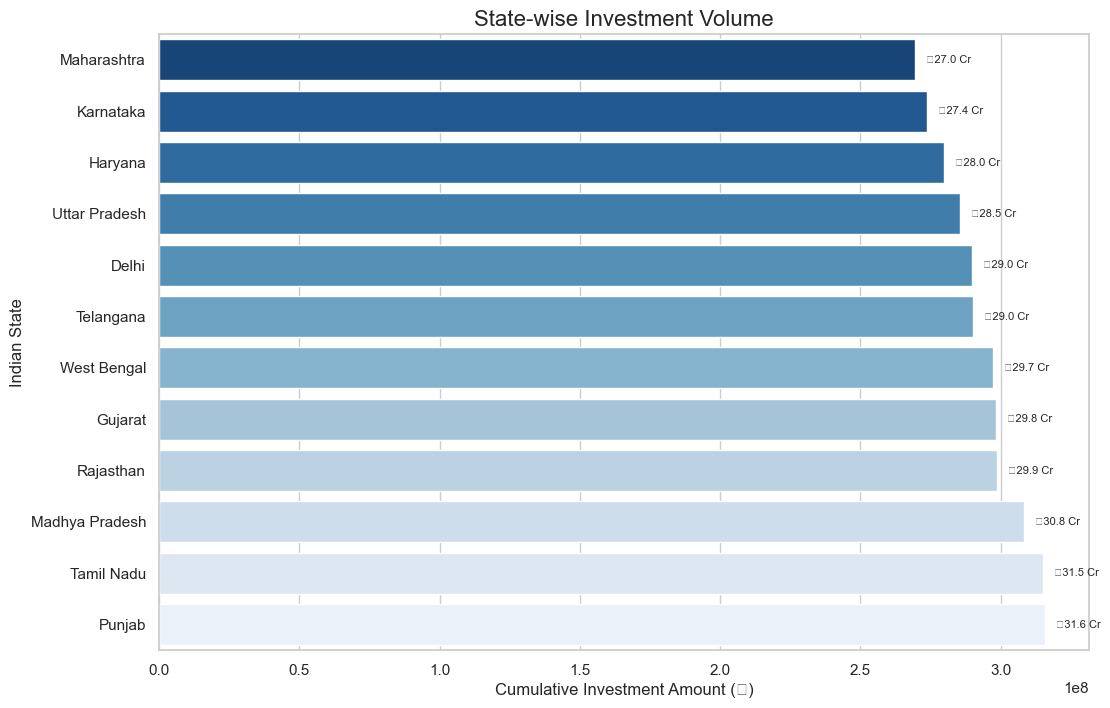

In [18]:
# Chart 9: State-wise Investment Volume.
state_bars = investor_df.groupby('state', as_index=False)['amount_inr'].sum().sort_values('amount_inr', ascending=False).head(15).copy()
state_bars = state_bars.sort_values('amount_inr')
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=state_bars, x='amount_inr', y='state', palette='Blues_r', ax=ax, order=state_bars['state'])
ax.set_title('State-wise Investment Volume')
ax.set_xlabel('Cumulative Investment Amount (₹)')
ax.set_ylabel('Indian State')
for patch, value in zip(ax.patches, state_bars['amount_inr']):
    ax.text(value + 4000000, patch.get_y() + patch.get_height()/2, f'₹{value/1e7:,.1f} Cr', va='center', ha='left', fontsize=8)
save_static_figure(fig, '09_state_bars.png')
plt.show()
plt.close(fig)


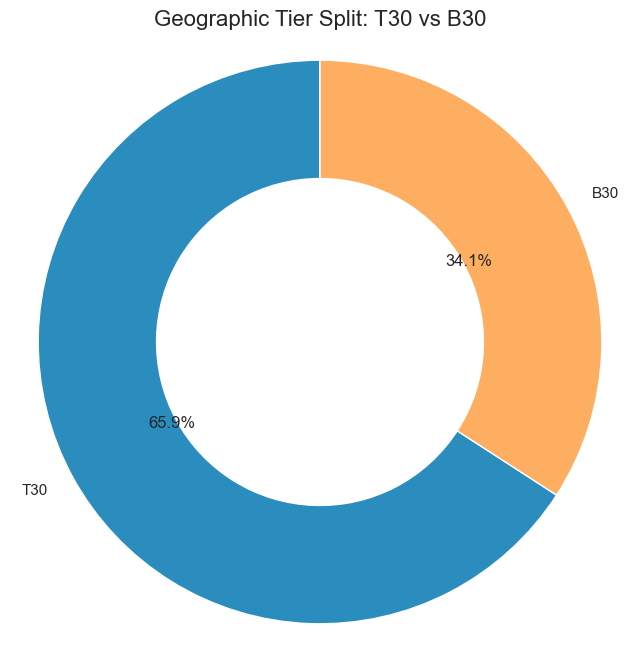

In [19]:
# Chart 10: Geographic Tier Split.
tier_counts = investor_df.groupby('city_tier')['amount_inr'].sum().reindex(['T30', 'B30']).fillna(0)
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90, colors=['#2b8cbe', '#fdae61'], wedgeprops=dict(width=0.42, edgecolor='white'))
ax.add_artist(plt.Circle((0, 0), 0.52, fc='white'))
ax.set_title('Geographic Tier Split: T30 vs B30')
ax.axis('equal')
save_static_figure(fig, '10_tier_donut.png')
plt.show()
plt.close(fig)


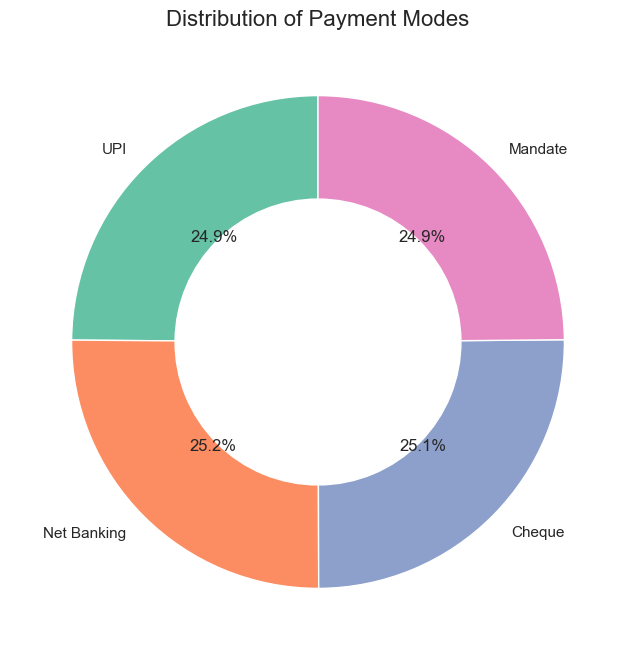

In [20]:
# Chart 13: Distribution of Payment Modes.
payment_order = ['UPI', 'Net Banking', 'Cheque', 'Mandate']
payment_counts = investor_df['payment_mode'].value_counts().reindex(payment_order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', len(payment_counts)), wedgeprops=dict(width=0.42, edgecolor='white'))
ax.set_title('Distribution of Payment Modes')
save_static_figure(fig, '13_payment_distribution.png')
plt.show()
plt.close(fig)


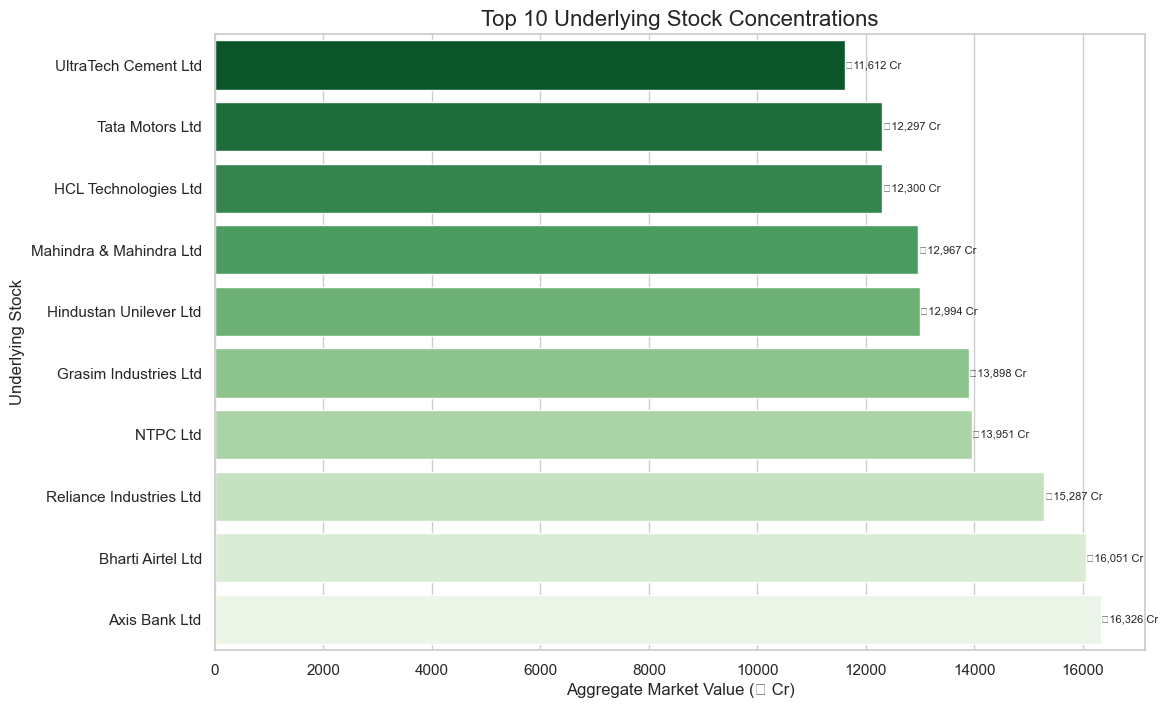

In [21]:
# Chart 14: Top 10 Underlying Stock Concentrations.
stock_conc = holdings_df.groupby('stock_name', as_index=False)['market_value_cr'].sum().sort_values('market_value_cr', ascending=False).head(10).copy()
stock_conc = stock_conc.sort_values('market_value_cr')
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=stock_conc, x='market_value_cr', y='stock_name', palette='Greens_r', ax=ax)
ax.set_title('Top 10 Underlying Stock Concentrations')
ax.set_xlabel('Aggregate Market Value (₹ Cr)')
ax.set_ylabel('Underlying Stock')
for patch, value in zip(ax.patches, stock_conc['market_value_cr']):
    ax.text(value + 10, patch.get_y() + patch.get_height()/2, f'₹{value:,.0f} Cr', va='center', ha='left', fontsize=8)
save_static_figure(fig, '14_top_stock_holdings.png')
plt.show()
plt.close(fig)


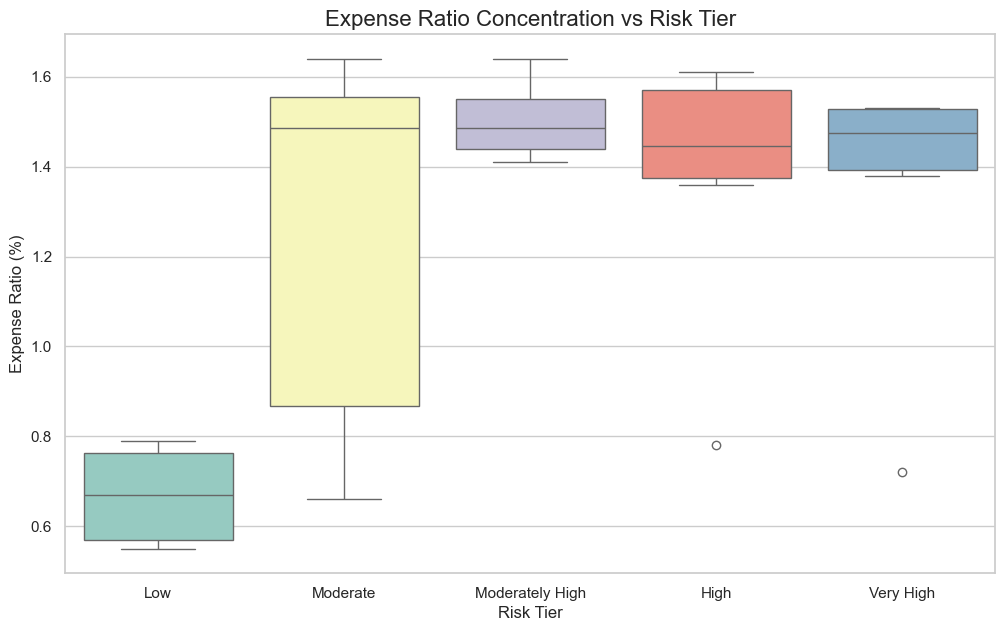

In [22]:
# Chart 15: Expense Ratio Concentration Profile.
risk_order = ['Low', 'Moderate', 'Moderately High', 'High', 'Very High']
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=performance_df, x='risk_grade', y='expense_ratio_pct', order=risk_order, palette='Set3', ax=ax)
ax.set_title('Expense Ratio Concentration vs Risk Tier')
ax.set_xlabel('Risk Tier')
ax.set_ylabel('Expense Ratio (%)')
save_static_figure(fig, '15_expense_vs_risk.png')
plt.show()
plt.close(fig)


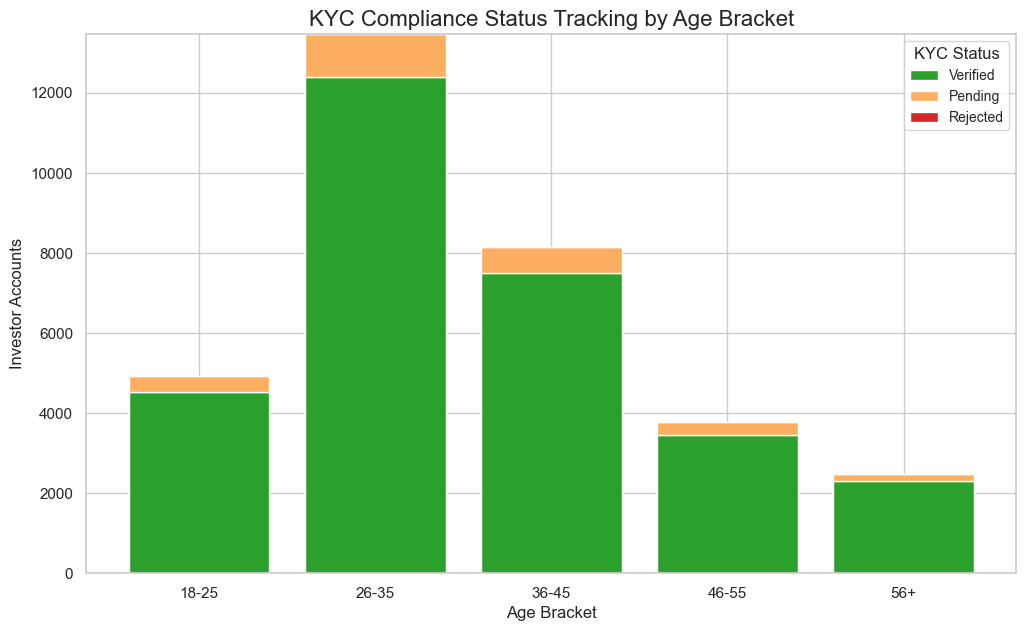

In [23]:
# Chart 16: KYC Compliance Status Tracking.
kyc_order = ['Verified', 'Pending', 'Rejected']
kyc_matrix = investor_df.groupby(['age_group', 'kyc_status']).size().unstack(fill_value=0).reindex(age_order).reindex(columns=kyc_order, fill_value=0)
fig, ax = plt.subplots(figsize=(12, 7))
bottom = np.zeros(len(kyc_matrix))
palette = {'Verified': '#2ca02c', 'Pending': '#fdae61', 'Rejected': '#d62728'}
for status in kyc_order:
    ax.bar(kyc_matrix.index, kyc_matrix[status], bottom=bottom, label=status, color=palette[status])
    bottom += kyc_matrix[status].values
ax.set_title('KYC Compliance Status Tracking by Age Bracket')
ax.set_xlabel('Age Bracket')
ax.set_ylabel('Investor Accounts')
ax.legend(title='KYC Status', frameon=True)
save_static_figure(fig, '16_kyc_compliance.png')
plt.show()
plt.close(fig)


## Executive Summary Findings

The NAV trend lines show a synchronized regime lift in 2023 followed by a corrective reset in 2024, confirming that scheme prices remain tightly linked to market cycles (Ref: reports/01_nav_trends.html).

SBI Mutual Fund’s AUM dominance peaks at ₹12.5 lakh crore, proving the industry’s balance-sheet power is still heavily concentrated in one AMC (Ref: reports/04_aum_growth.png).

Monthly SIP inflows accelerated into a structural step-up and closed at the record-high ₹31,002 crore in December 2025, showing that automated retail accumulation stayed resilient through volatility (Ref: reports/02_sip_inflows.html).

The folio base climbed from 13.26 crore to 26.12 crore, which is a clear milestone that household participation is still expanding structurally (Ref: reports/03_folio_growth.html).

The category heatmap shows repeated risk-on clustering in Mid Cap, Small Cap, and ELSS while Liquid remains the defensive parking lane, signaling a barbell retail risk posture (Ref: reports/05_category_heatmap.png).

The SIP boxplot shows ticket sizes widen as age rises, with older investor buckets carrying larger and more variable contribution sizes that deserve tighter suitability checks (Ref: reports/07_sip_boxplot.png).

The gender split remains male-skewed, so distribution teams still have a sizable inclusion gap to close before participation looks structurally balanced (Ref: reports/08_gender_split.png).

State-wise investment value concentrates in a handful of non-metro clusters, which confirms that regional velocity is now a real growth engine rather than a peripheral story (Ref: reports/09_state_bars.png).

The return-correlation matrix shows the core schemes still move in a tightly coupled cluster, which means diversification benefits remain constrained by common market beta (Ref: reports/11_return_correlation.png).

The sector donut reveals concentrated exposure in a few macro sectors, so portfolio risk remains vulnerable to synchronized valuation shocks even when scheme count looks diversified (Ref: reports/12_sector_donut.png).